<a href="https://colab.research.google.com/github/dallinmoore/DATA_5630_Deep_Forecasting/blob/main/Homework(my-branch-only)/HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW 7 - DATA 5630
Dallin Moore & Alesandro Rodriguez

## Dependencies

In [ ]:
!pip install pycaret[full]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

## Q1


In [ ]:
stocks = pd.read_csv("https://raw.githubusercontent.com/PJalgotrader/Deep_forecasting-USU/main/data/yfinance.csv", index_col=0, header=[0,1])
stocks.head()

Adj Close                                                 \
                 AAPL         GLD       MSFT         QQQ         SPY   
Date                                                                   
2018-01-02  40.722874  125.150002  80.229012  152.072800  243.072266   
2018-01-03  40.715786  124.820000  80.602394  153.550400  244.609711   
2018-01-04  40.904907  125.459999  81.311806  153.819046  245.640732   
2018-01-05  41.370617  125.330002  82.319908  155.363861  247.277679   
2018-01-08  41.216949  125.309998  82.403923  155.968399  247.729935   

                                      Close                         ...  \
                 TSLA        USO       AAPL         GLD       MSFT  ...   
Date                                                                ...   
2018-01-02  21.368668  96.559998  43.064999  125.150002  85.949997  ...   
2018-01-03  21.150000  98.720001  43.057499  124.820000  86.349998  ...   
2018-01-04  20.974667  98.959999  43.257500  125.459999  87.110001  ...   
2018-01-05  21.105333  98.480003  43.750000  125.330002  88.190002  ...   
2018-01-08  22.427334  99.040001  43.587502  125.309998  88.279999  ...   

                  Open                           Volume                      \
                   SPY       TSLA        USO       AAPL       GLD      MSFT   
Date                                                                          
2018-01-02  267.839996  20.799999  96.559998  102223600  11762500  22483800   
2018-01-03  268.959991  21.400000  97.360001  118071600   7904300  26061400   
2018-01-04  271.200012  20.858000  98.639999   89738400   7329700  21912000   
2018-01-05  272.510010  21.108000  98.239998   94640000   5739900  23407100   
2018-01-08  273.309998  21.066668  98.480003   82271200   3566700  22113000   

                                                    
                 QQQ       SPY       TSLA      USO  
Date                                                
2018-01-02  32573300  86655700   65283000  1497588  
2018-01-03  29383600  90070400   67822500  2156150  
2018-01-04  24776100  80636400  149194500  1480988  
2018-01-05  26992300  83524000   68868000  1609888  
2018-01-08  23159100  57319200  147891000  1229225  

[5 rows x 42 columns]

In [ ]:
stocks.index

Index(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05', '2018-01-08',
       '2018-01-09', '2018-01-10', '2018-01-11', '2018-01-12', '2018-01-16',
       ...
       '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20', '2023-12-21',
       '2023-12-22', '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29'],
      dtype='object', name='Date', length=1509)

In [ ]:
stocks.index = pd.to_datetime(stocks.index).to_period('B')
stocks.index

PeriodIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
             '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
             '2018-01-12', '2018-01-16',
             ...
             '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
             '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
             '2023-12-28', '2023-12-29'],
            dtype='period[B]', name='Date', length=1509)

In [ ]:
df = stocks['Close'][['GLD']]
df.head()

,GLD
Date,
2018-01-02,125.150002
2018-01-03,124.820000
2018-01-04,125.459999
2018-01-05,125.330002
2018-01-08,125.309998


In [ ]:
df.index

PeriodIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
             '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
             '2018-01-12', '2018-01-16',
             ...
             '2023-12-15', '2023-12-18', '2023-12-19', '2023-12-20',
             '2023-12-21', '2023-12-22', '2023-12-26', '2023-12-27',
             '2023-12-28', '2023-12-29'],
            dtype='period[B]', name='Date', length=1509)

In [ ]:
idx = pd.period_range(min(df.index), max(df.index))
idx

PeriodIndex(['2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05',
             '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11',
             '2018-01-12', '2018-01-15',
             ...
             '2023-12-18', '2023-12-19', '2023-12-20', '2023-12-21',
             '2023-12-22', '2023-12-25', '2023-12-26', '2023-12-27',
             '2023-12-28', '2023-12-29'],
            dtype='period[B]', length=1564)

In [ ]:
df.index.symmetric_difference(idx)

PeriodIndex(['2018-01-15', '2018-02-19', '2018-03-30', '2018-05-28',
             '2018-07-04', '2018-09-03', '2018-11-22', '2018-12-05',
             '2018-12-25', '2019-01-01', '2019-01-21', '2019-02-18',
             '2019-04-19', '2019-05-27', '2019-07-04', '2019-09-02',
             '2019-11-28', '2019-12-25', '2020-01-01', '2020-01-20',
             '2020-02-17', '2020-04-10', '2020-05-25', '2020-07-03',
             '2020-09-07', '2020-11-26', '2020-12-25', '2021-01-01',
             '2021-01-18', '2021-02-15', '2021-04-02', '2021-05-31',
             '2021-07-05', '2021-09-06', '2021-11-25', '2021-12-24',
             '2022-01-17', '2022-02-21', '2022-04-15', '2022-05-30',
             '2022-06-20', '2022-07-04', '2022-09-05', '2022-11-24',
             '2022-12-26', '2023-01-02', '2023-01-16', '2023-02-20',
             '2023-04-07', '2023-05-29', '2023-06-19', '2023-07-04',
             '2023-09-04', '2023-11-23', '2023-12-25'],
            dtype='period[B]')

In [ ]:
df = df.reindex(idx, fill_value=np.nan)
df.tail()

,GLD
2023-12-25,NaN
2023-12-26,191.720001
2023-12-27,192.589996
2023-12-28,191.470001
2023-12-29,191.169998


In [ ]:
df = df.fillna(method='ffill')
df.tail(10)

,GLD
2023-12-18,187.850006
2023-12-19,189.130005
2023-12-20,188.100006
2023-12-21,189.429993
2023-12-22,190.270004
2023-12-25,190.270004
2023-12-26,191.720001
2023-12-27,192.589996
2023-12-28,191.470001
2023-12-29,191.169998


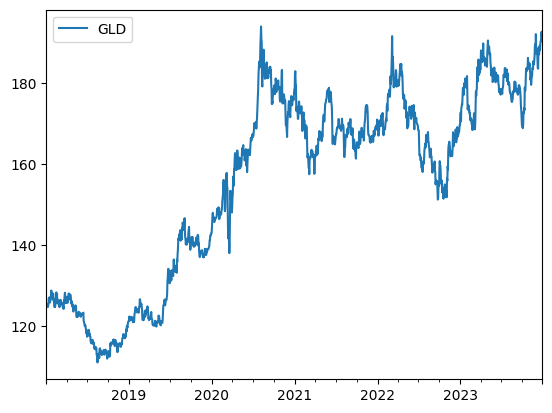

In [ ]:
df.plot()
plt.show()

The price shows periods of clear upward movement followed by relatively flat or oscillating periods. These changes in trend or level suggest a non-constant mean over time. The price appears to also be more volatile during certain times suggesting the variance not constant either, again suggesting non-stationarity. However, statistical tests would give a more definitive answer about non-stationarity.

## Q2

In [ ]:
# Calculate LogReturn
df['LogReturn'] = np.log(df['GLD']) - np.log(df['GLD'].shift(1))
df.head()

,GLD,LogReturn
2018-01-02,125.150002,NaN
2018-01-03,124.820000,-0.002640
2018-01-04,125.459999,0.005114
2018-01-05,125.330002,-0.001037
2018-01-08,125.309998,-0.000160


## Q3

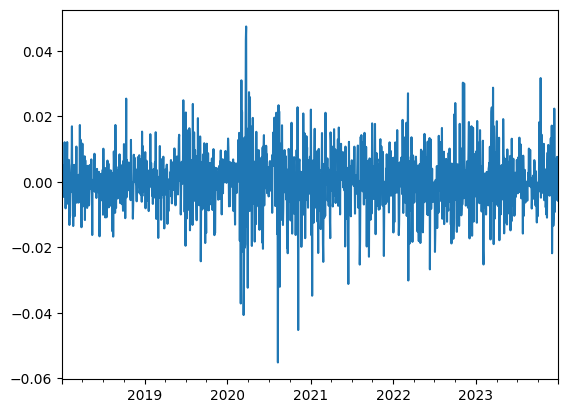

In [ ]:
df['LogReturn'].plot()
plt.show()

The mean is constant. The variance is not necessarily constant, but it is otherwise stationary and we will assume weak-stationarity.

## Q4

In [ ]:
num_train_samples = int(0.6 * len(df))
num_val_samples = int(0.20 * len(df))
num_test_samples = len(df) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 938
num_val_samples: 312
num_test_samples: 314


## Q5

In [ ]:
series = df['LogReturn'].dropna().to_numpy().reshape(-1, 1)
sequence_length = 60
h = 1
delay = sequence_length  + h - 1
batch_size = 32

train_dataset = keras.utils.timeseries_dataset_from_array(
    data = series[:-delay],
    targets=series[delay:],
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data = series[:-delay],
    targets=series[delay:],
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data = series[:-delay],
    targets=series[delay:],
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

In [ ]:
import tensorflow as tf


In [ ]:
for ds_name, dataset in [("train", train_dataset), ("val", val_dataset), ("test", test_dataset)]:
    for x, y in dataset.take(1):
        print(f"{ds_name} input has NaN:", tf.reduce_any(tf.math.is_nan(x)).numpy())
        print(f"{ds_name} target has NaN:", tf.reduce_any(tf.math.is_nan(y)).numpy())


train input has NaN: False
train target has NaN: False
val input has NaN: False
val target has NaN: False
test input has NaN: False
test target has NaN: False


## Q6

In [ ]:
sample_seen = 0
total_abs_err = 0.
for inputs, targets in test_dataset:
  preds = inputs[:, -1]
  sample_seen += inputs.shape[0]


print(sample_seen)
print(preds)

194
tf.Tensor(
[[-0.00183447]
 [ 0.00513985]], shape=(2, 1), dtype=float64)


In [ ]:
def evaluate_naive_method(dataset):
    total_abs_err = 0. # Initializes a variable to accumulate the total absolute error of the predictions. This is a floating-point variable, as indicated by the .0.
    samples_seen = 0   # Initializes a counter for the total number of samples (data points) seen during the evaluation.
    for samples, targets in dataset:
        preds = samples[:, -1] # naive forecast is the last value observed in the sequence
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0] # number of samples in the batch
    return total_abs_err / samples_seen

In [ ]:
print(f"Train MAE: {evaluate_naive_method(train_dataset):.2f}")
print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

# the unit is DiffLogPassengers

Train MAE: 0.01
Validation MAE: 0.01
Test MAE: 0.01


## Q7

In [98]:
n_features = 1

In [99]:
inputs = keras.Input(shape=(sequence_length, n_features))
x = layers.SimpleRNN(64, return_sequences=False)(inputs)

outputs = layers.Dense(1)(x)
model_RNN = keras.Model(inputs, outputs)

model_RNN.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 60, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_4 (SimpleRNN)             │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

In [100]:
callbacks = [
    keras.callbacks.ModelCheckpoint("RNN.keras",
                                    save_best_only=True)
]
model_RNN.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model_RNN.fit(train_dataset,
                    epochs=20,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0119 - mae: 0.0450 - val_loss: 1.8351e-04 - val_mae: 0.0106
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 1.2422e-04 - mae: 0.0085 - val_loss: 1.5650e-04 - val_mae: 0.0099
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.3196e-04 - mae: 0.0087 - val_loss: 2.0061e-04 - val_mae: 0.0113
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.3475e-04 - mae: 0.0090 - val_loss: 1.5629e-04 - val_mae: 0.0100
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 1.0892e-04 - mae: 0.0079 - val_loss: 1.3454e-04 - val_mae: 0.0092
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 9.3424e-05 - mae: 0.0072 - val_loss: 1.2624e-04 - val_mae: 0.0089
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.5166e-05 - mae: 0.0069 - val_loss: 1.2416e-04 - val_mae: 0.0088
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7.9855e-05 - mae: 0.0066 - val_loss: 1.2464e-04 - val_mae: 0.0089
Epoc

In [101]:
# model = keras.models.load_model("RNN.keras")
print(f"Test MAE: {model_RNN.evaluate(test_dataset)[1]:.3f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1040e-04 - mae: 0.0080
Test MAE: 0.008


In [102]:
loss_df = pd.DataFrame(history.history)
loss_df.tail()

,loss,mae,val_loss,val_mae
15,0.000090,0.006804,0.000114,0.008552
16,0.000089,0.006725,0.000114,0.008538
17,0.000088,0.006707,0.000112,0.008447
18,0.000087,0.006657,0.000111,0.008436
19,0.000087,0.006640,0.000110,0.008375


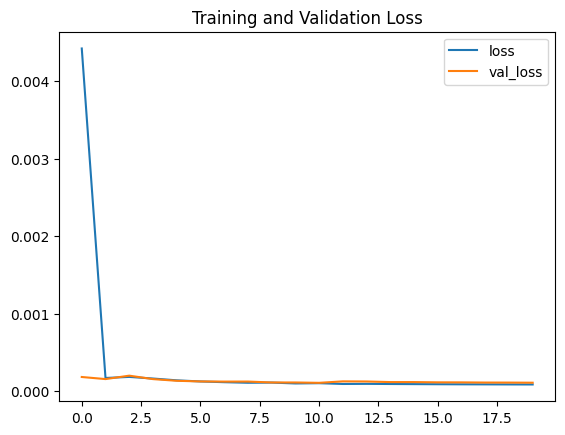

In [103]:
loss_df[['loss', 'val_loss']].plot(legend=True, title='Training and Validation Loss')
plt.show()

## Q8

In [104]:
mae_df = pd.DataFrame(history.history)
mae_df.tail()

,loss,mae,val_loss,val_mae
15,0.000090,0.006804,0.000114,0.008552
16,0.000089,0.006725,0.000114,0.008538
17,0.000088,0.006707,0.000112,0.008447
18,0.000087,0.006657,0.000111,0.008436
19,0.000087,0.006640,0.000110,0.008375


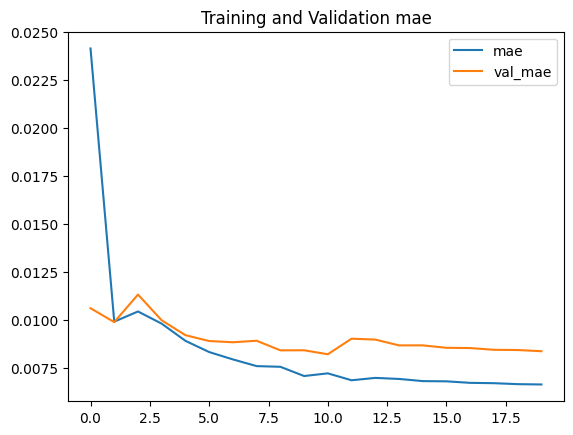

In [105]:
mae_df[['mae', 'val_mae']].plot(legend=True, title='Training and Validation mae')
plt.show()

## Q9

In [106]:
inputs = keras.Input(shape=(sequence_length, n_features))
x = layers.LSTM(64, return_sequences=False)(inputs)

outputs = layers.Dense(1)(x)
model_LSTM = keras.Model(inputs, outputs)

model_LSTM.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 60, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
callbacks = [
    keras.callbacks.ModelCheckpoint("LSTM.keras",
                                    save_best_only=True)
]
model_LSTM.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model_LSTM.fit(train_dataset,
                    epochs=40,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 1.2251e-04 - mae: 0.0080 - val_loss: 1.2542e-04 - val_mae: 0.0092
Epoch 2/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 8.5041e-05 - mae: 0.0069 - val_loss: 1.3238e-04 - val_mae: 0.0095
Epoch 3/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 8.5676e-05 - mae: 0.0069 - val_loss: 1.3091e-04 - val_mae: 0.0095
Epoch 4/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 8.5120e-05 - mae: 0.0069 - val_loss: 1.2964e-04 - val_mae: 0.0094
Epoch 5/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 8.4538e-05 - mae: 0.0069 - val_loss: 1.2843e-04 - val_mae: 0.0093
Epoch 6/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 8.3984e-05 - mae: 0.0068 - val_loss: 1.2728e-04 - val_mae: 0.0093
Epoch 7/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 8.3454e-05 - mae: 0.0068 - val_loss: 1.2618e-04 - val_mae: 0.0092
Epoch 8/40
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 8.2945e-05 - mae: 0.0068 - val_loss: 1.2513e-04 - val_mae: 0.0092


In [108]:
# model = keras.models.load_model("LSTM.keras")
print(f"Test MAE: {model_LSTM.evaluate(test_dataset)[1]:.3f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.0659e-04 - mae: 0.0081
Test MAE: 0.008


## Q10

In [109]:
mae_df = pd.DataFrame(history.history)
mae_df.tail()

,loss,mae,val_loss,val_mae
35,0.000101,0.007128,0.000108,0.008413
36,0.000101,0.007119,0.000107,0.008397
37,0.000100,0.007110,0.000107,0.008381
38,0.000100,0.007101,0.000107,0.008366
39,0.000100,0.007093,0.000106,0.008350


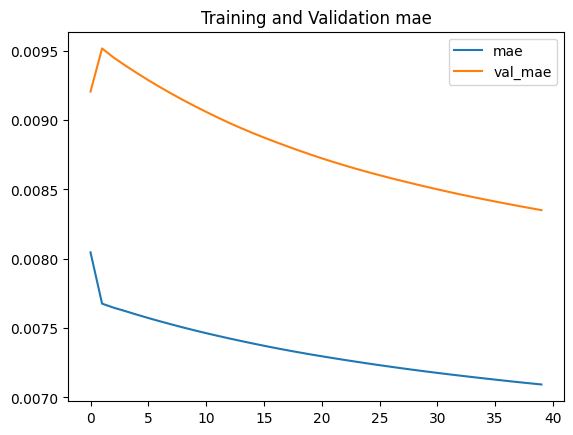

In [110]:
mae_df[['mae', 'val_mae']].plot(legend=True, title='Training and Validation mae')
plt.show()

## Q11

In [111]:
inputs = keras.Input(shape=(sequence_length, n_features))

# Stacked recurrent layers
x = layers.LSTM(128, return_sequences=True, recurrent_dropout=0.1)(inputs)
x = layers.SimpleRNN(128, recurrent_dropout=0.1)(x)

# Dropout layer
x = layers.Dropout(0.1)(x)

# Output layer
outputs = layers.Dense(1)(x)

# Model
model_stacked = keras.Model(inputs, outputs)

model_stacked.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)           │ (None, 60, 1)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 60, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_5 (SimpleRNN)             │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 99,585 (389.00 KB)

 Trainable params: 99,585 (389.00 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
callbacks = [
    keras.callbacks.ModelCheckpoint("stacked_rnn.keras",
                                    save_best_only=True)
]
model_stacked.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model_stacked.fit(train_dataset,
                    epochs=20,
                    validation_data=val_dataset,
                    callbacks=callbacks)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 215ms/step - loss: 0.0359 - mae: 0.1204 - val_loss: 1.1086e-04 - val_mae: 0.0082
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - loss: 0.0019 - mae: 0.0291 - val_loss: 7.8259e-05 - val_mae: 0.0068
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - loss: 1.9492e-04 - mae: 0.0104 - val_loss: 1.1597e-04 - val_mae: 0.0085
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 2.7508e-04 - mae: 0.0123 - val_loss: 3.8525e-04 - val_mae: 0.0177
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - loss: 2.7152e-04 - mae: 0.0130 - val_loss: 2.2081e-04 - val_mae: 0.0129
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 1.6754e-04 - mae: 0.0102 - val_loss: 8.4818e-05 - val_mae: 0.0073
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - loss: 1.6125e-04 - mae: 0.0100 - val_loss: 9.9072e-05 - val_mae: 0.0080
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 1.3428e-04 - mae: 0.0089 - val_loss: 1.2972e-04 - val_mae: 0.0094

In [113]:
# model = keras.models.load_model("stacked_rnn.keras")
print(f"Test MAE: {model_stacked.evaluate(test_dataset)[1]:.3f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.0205e-04 - mae: 0.0078
Test MAE: 0.007


## Q12

In [114]:
mae_df = pd.DataFrame(history.history)
mae_df.tail()

,loss,mae,val_loss,val_mae
15,0.000142,0.008891,0.000087,0.007423
16,0.000131,0.008574,0.000085,0.007278
17,0.000136,0.008760,0.000138,0.009754
18,0.000129,0.008460,0.000085,0.007296
19,0.000127,0.008391,0.000099,0.008042


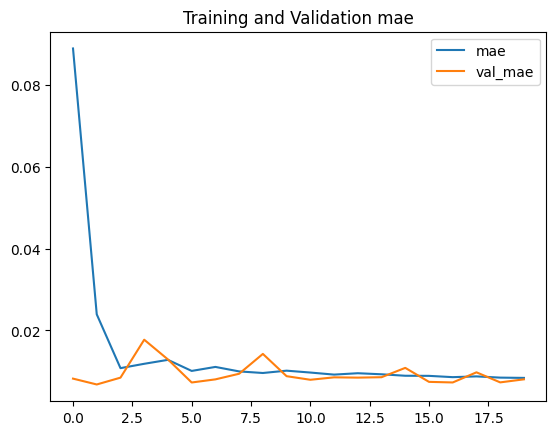

In [115]:
mae_df[['mae', 'val_mae']].plot(legend=True, title='Training and Validation mae')
plt.show()

## Q13

The MAE for the stacked model (MAE=0.007) is .001 better than the RNN (MAE=0.008) or LSTM model (MAE=0.008) and 0.003 better than the naive (MAE=0.010) forecast.

In [117]:
# Convert predicted log returns to price
start_price = df['GLD'].dropna().iloc[num_train_samples + num_val_samples + sequence_length - 1]

# Transform log returns back to prices
def log_return_to_price(start_price, log_returns):
    return start_price * np.exp(np.cumsum(log_returns))

rnn_prices = log_return_to_price(start_price, rnn_preds)
lstm_prices = log_return_to_price(start_price, lstm_preds)
stacked_prices = log_return_to_price(start_price, stacked_preds)
actual_prices = log_return_to_price(start_price, rnn_actuals)  # all actuals are the same for comparison


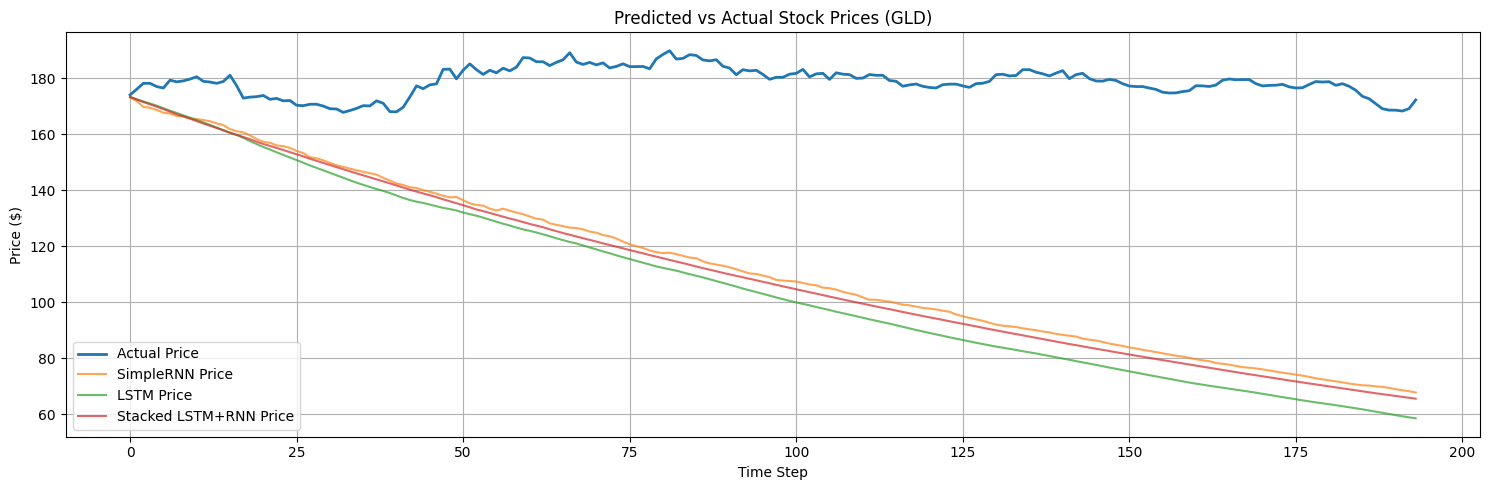

In [118]:
plt.figure(figsize=(15, 5))

plt.plot(actual_prices, label="Actual Price", linewidth=2)
plt.plot(rnn_prices, label="SimpleRNN Price", alpha=0.7)
plt.plot(lstm_prices, label="LSTM Price", alpha=0.7)
plt.plot(stacked_prices, label="Stacked LSTM+RNN Price", alpha=0.7)

plt.title("Predicted vs Actual Stock Prices (GLD)")
plt.xlabel("Time Step")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
